In [1]:
### Function Eight

In [3]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from scipy.stats import norm

In [6]:
X = np.load("function_8/initial_inputs.npy")
X = np.append(X, [
    [0.086742, 0.044878, 0.148373, 0.000001, 0.999999, 0.413900, 0.087100, 0.893100],
    [0.000050, 0.061737, 0.126822, 0.000050, 0.552527, 0.573729, 0.000050, 0.241814],
    [0.098365, 0.321694, 0.274773, 0.563393, 0.976643, 0.743288, 0.479267, 0.023731],
    [0.192356, 0.238634, 0.002279, 0.665361, 0.957875, 0.024156, 0.268708, 0.867175],
    [0.819043, 0.132636, 0.053945, 0.334416, 0.511216, 0.943375, 0.072411, 0.603372],
    [0.285072, 0.672366, 0.176750, 0.947100, 0.838174, 0.889650, 0.128810, 0.076014],
    [0.361520, 0.002760, 0.223279, 0.107328, 0.848316, 0.160880, 0.060393, 0.238034],
    [0.094562, 0.649763, 0.027938, 0.386260, 0.230417, 0.057540, 0.368588, 0.547980],
    [0.000099, 0.999999, 0.000099, 0.000099, 0.999999, 0.999999, 0.000099, 0.999999],
    [0.000099, 0.000099, 0.611296, 0.000099, 0.999900, 0.999900, 0.999900, 0.999900],
    [0.000001, 0.000001, 0.628520, 0.000001, 0.999999, 0.999999, 0.000001, 0.000001],
    [0.043396, 0.053307, 0.137597, 0.000025, 0.776263, 0.493814, 0.043575, 0.567457]
        ],
    axis=0)

In [7]:
y= np.load("function_8/initial_outputs.npy")
y = np.append(y, [
    9.9035888235995,
    9.8208672019139,
    9.4727652505954,
    9.405080233989,
    8.6434519368416,
    8.8265574595184,
    9.6453593867514,
    9.2480113729385,
    8.818528621589401,
    7.674609405948,
    8.8034365487924,
    9.9122133391516,
    9.8426052732766
        ],
    axis=0)

In [8]:
max(y)

9.9122133391516

In [6]:
X


array([[6.04994453e-01, 2.92215020e-01, 9.08452748e-01, 3.55506242e-01,
        2.01668719e-01, 5.75338005e-01, 3.10310951e-01, 7.34281377e-01],
       [1.78006959e-01, 5.66222654e-01, 9.94861845e-01, 2.10325006e-01,
        3.20152657e-01, 7.07908792e-01, 6.35384489e-01, 1.07131627e-01],
       [9.07697668e-03, 8.11626153e-01, 5.20520360e-01, 7.56866752e-02,
        2.65111825e-01, 9.16516894e-02, 5.92415145e-01, 3.67320262e-01],
       [5.06028164e-01, 6.53730123e-01, 3.63410779e-01, 1.77981049e-01,
        9.37283044e-02, 1.97425331e-01, 7.55826900e-01, 2.92472339e-01],
       [3.59909264e-01, 2.49075679e-01, 4.95997170e-01, 7.09214981e-01,
        1.14987195e-01, 2.89206921e-01, 5.57295151e-01, 5.93881726e-01],
       [7.78818344e-01, 3.41949948e-03, 3.37983130e-01, 5.19527778e-01,
        8.20906993e-01, 5.37246689e-01, 5.51347098e-01, 6.60032086e-01],
       [9.08649322e-01, 6.22496998e-02, 2.38259546e-01, 7.66603545e-01,
        1.32335962e-01, 9.90243814e-01, 6.88067822e-01, 7.

In [7]:
y

array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
       8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
       7.85454099, 6.79198578, 8.97655402, 7.3790829 , 9.598482  ,
       8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
       7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
       8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
       7.92375877, 8.42175924, 8.2780624 , 7.11345716, 6.40258841,
       8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525,
       9.90358882, 9.8208672 , 9.47276525, 9.40508023, 8.64345194,
       8.82655746, 9.64535939, 9.24801137, 8.81852862, 7.67460941])

In [8]:



# 1. Setup for 8 Dimensions
d = 8
n_starts = 64  # Increased for 8D complexity
current_best_y = np.max(y)

# Giving each of the 8 dimensions its own length_scale allows the GP 
# to learn which inputs are actually driving the 9.90 output.
kernel = C(1.0) * Matern(length_scale=[0.5]*d, 
                         length_scale_bounds=(0.01, 10), 
                         nu=2.5) + WhiteKernel(noise_level=1)

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25)
gp.fit(X, y)




/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-poXcNCb8-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-poXcNCb8-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",1**2 * Matern...noise_level=1)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",25
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

In [9]:
# 1. Get the optimized kernel object
optimized_kernel = gp.kernel_

# 2. Extract the length scales from the Matern component
# In a Product kernel (C * Matern), 'k2' is typically the second component
length_scales = optimized_kernel.get_params()['k1__k2__length_scale']

# 3. Print them alongside the bounds you set
print("--- Hyperparameter Check ---")
for i, ls in enumerate(length_scales):
    print(f"Parameter x{i+1} Length Scale: {ls:.4f}")

# Check if we are hitting the limits (assuming bounds were 0.01 to 10.0)
if np.any(np.isclose(length_scales, 0.01)) or np.any(np.isclose(length_scales, 10.0)):
    print("\nWARNING: One or more length scales are hitting the bounds. Consider widening 'length_scale_bounds'.")

--- Hyperparameter Check ---
Parameter x1 Length Scale: 3.0445
Parameter x2 Length Scale: 4.3881
Parameter x3 Length Scale: 2.3843
Parameter x4 Length Scale: 4.5851
Parameter x5 Length Scale: 7.1569
Parameter x6 Length Scale: 4.4070
Parameter x7 Length Scale: 3.0938
Parameter x8 Length Scale: 10.0000



In [10]:


# 2. To specifically get the noise level:
# In your setup (Matern + WhiteKernel), k2 is the WhiteKernel
optimized_noise = gp.kernel_.k2.noise_level
print(f"\nOptimized Noise Level: {optimized_noise:.6f}")

# 3. To see the ARD Importance (Length Scales):
# k1 is the (C * Matern) part, so k1.k2 is the Matern part
scales = gp.kernel_.k1.k2.length_scale
print(f"Optimized Length Scales: {scales}")


Optimized Noise Level: 0.000010
Optimized Length Scales: [ 3.04454205  4.38810965  2.3842958   4.58509008  7.15689917  4.40701021
  3.09375325 10.        ]


In [11]:
# 3. Expected Improvement (EI) Function
def expected_improvement(x_test, gp, y_max, xi=0.01):
    """
    xi=1.0 is a high exploration parameter for 8D.
    It forces the model to look for points that could beat 9.90 by a 
    significant margin.
    """
    x_test = np.atleast_2d(x_test)
    mu, sigma = gp.predict(x_test, return_std=True)
    
    sigma = np.maximum(sigma, 1e-9) # Prevent division by zero
    
    imp = mu - y_max - xi
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    
    return -ei.flatten() # Negative for minimize()

In [12]:
from scipy.stats import qmc, norm

# 4. Multi-Start Optimization using Sobol Sequence
sampler = qmc.Sobol(d=d, scramble=True)
initial_guesses = sampler.random(n=n_starts)

best_ei_found = np.inf
best_next_point = None

for x0 in initial_guesses:
    res = minimize(
        expected_improvement, 
        x0, 
        args=(gp, current_best_y, 1.0), # xi set to 1.0 for exploration
        bounds=[(0, 1)] * d, 
        method='L-BFGS-B'
    )
    
    if res.fun < best_ei_found:
        best_ei_found = res.fun
        best_next_point = res.x

print(f"Suggested Next 8D Point: {best_next_point}")



Suggested Next 8D Point: [0.02948217 0.06782199 0.35416789 0.50486312 0.94903709 0.60260517
 0.02086414 0.97658131]


In [13]:
# Third iteration

In [14]:
def ucb_loss(x_test, kappa=10):
    """
    UCB Acquisition Function
    kappa=2.576 corresponds to a 99% confidence interval.
    Common values: 1.0 (exploitative) to 5.0+ (exploratory).
    """
    mu, sigma = gp.predict(x_test.reshape(1, -1), return_std=True)
    
    # UCB Formula
    ucb = mu + kappa * sigma
    
    # Return NEGATIVE because 'minimize' will find the highest score
    return -ucb

In [16]:
x_init = X[np.argmax(y)] # Start from current best
res = minimize(ucb_loss, x_init, bounds=[(0, 1)]*8, method='L-BFGS-B')

print(f"Current Best Y: {np.max(y)}")
print(f"Next Suggested Point: {res.x}")

Current Best Y: 9.9035888235995
Next Suggested Point: [0.         0.         0.62852015 0.         1.         1.
 0.         0.        ]


In [17]:
# Fourth iteration
# tighten the length scales

# Lowering the upper bound of length_scale_bounds from 10.0 to 1.0 or 2.0
# forces the model to acknowledge that there is 'detail' in the landscape.
kernel = C(1.0) * Matern(
    length_scale=[0.2]*d,            # Start with a more sensitive 'guess'
    length_scale_bounds=(0.01, 1.0), # Force the model to see detail within the 0-1 range
    nu=2.5
) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-6, 1e-4))

In [18]:
next_point = best_next_point

In [19]:
import numpy as np


# 1. Get the indices that would sort the array from lowest to highest
sorted_indices = np.argsort(y)

# 2. Use those indices to get the sorted values
sorted_values = y[sorted_indices]

# 3. Display the Rank, Original Index, and Value
print(f"{'Rank':<6} | {'Orig Index':<10} | {'Value':<10}")
print("-" * 32)
for rank, idx in enumerate(sorted_indices):
    print(f"{rank:<6} | {idx:<10} | {sorted_values[rank]:.2f}")

Rank   | Orig Index | Value     
--------------------------------
0      | 9          | 5.59
1      | 21         | 5.84
2      | 34         | 6.40
3      | 24         | 6.45
4      | 17         | 6.77
5      | 11         | 6.79
6      | 27         | 6.89
7      | 1          | 7.01
8      | 33         | 7.11
9      | 16         | 7.13
10     | 7          | 7.30
11     | 20         | 7.31
12     | 6          | 7.33
13     | 13         | 7.38
14     | 0          | 7.40
15     | 18         | 7.43
16     | 38         | 7.44
17     | 37         | 7.46
18     | 49         | 7.67
19     | 29         | 7.69
20     | 10         | 7.85
21     | 30         | 7.92
22     | 8          | 7.96
23     | 36         | 7.98
24     | 28         | 8.04
25     | 15         | 8.16
26     | 32         | 8.28
27     | 3          | 8.28
28     | 31         | 8.42
29     | 2          | 8.46
30     | 35         | 8.47
31     | 5          | 8.54
32     | 4          | 8.61
33     | 44         | 8.64
34     | 23     

In [20]:
import torch
# Custom Labels: Start with all zeros (Negative)
y_labels = np.zeros(len(X))


positive_indices = [40,41,14,42,43,26,39,19]
y_labels[positive_indices] = 1

# 1. Setup Data
X_tensor = torch.tensor(X, dtype=torch.float32, requires_grad=True)

y_tensor = torch.tensor(y_labels, dtype=torch.float32).reshape(-1, 1)

In [21]:

import torch
import torch.nn as nn
import torch.optim as optim

# 1. Define a deeper architecture
model = nn.Sequential(
    nn.Linear(8, 64),      # Hidden layer: 2 inputs -> 10 neurons
    nn.ReLU(),             # Non-linear activation
    nn.Linear(64, 1),      # Output layer: 10 neurons -> 1 output
    nn.Sigmoid()
)

# 2. Setup the rest as before
optimizer = optim.Adam(model.parameters(), lr=0.01) # Adam is better for deeper nets
criterion = nn.BCELoss()

# 3. Training Loop
for _ in range(2000):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
       
# Importance scores
deep_importance = X_tensor.grad.abs().sum(dim=1).detach().numpy()

print("Point | Deep Importance Score")
for i, score in enumerate(deep_importance):
    print(f"{i:2d}    | {score:.4f}")


Point | Deep Importance Score
 0    | 0.3217
 1    | 2.3996
 2    | 3.1020
 3    | 0.3350
 4    | 5.2407
 5    | 2.4534
 6    | 0.9176
 7    | 0.2384
 8    | 0.2229
 9    | 0.1285
10    | 1.4756
11    | 0.1698
12    | 4.4908
13    | 0.2408
14    | 41.0669
15    | 0.4813
16    | 0.9684
17    | 0.2446
18    | 0.2806
19    | 37.0475
20    | 0.2627
21    | 0.1403
22    | 47.9290
23    | 0.6773
24    | 1.0449
25    | 44.0084
26    | 107.9239
27    | 0.2526
28    | 0.3888
29    | 1.6857
30    | 0.5181
31    | 0.7176
32    | 9.7005
33    | 0.1854
34    | 0.1157
35    | 5.2368
36    | 0.5438
37    | 0.3890
38    | 0.6525
39    | 64.3165
40    | 16.6327
41    | 5.6510
42    | 20.6340
43    | 10.4741
44    | 7.2493
45    | 48.6103
46    | 50.7972
47    | 27.1753
48    | 16.0507
49    | 5.9902


In [22]:
import torch

# 1. Prepare your sample input (must be a 2D tensor)
sample_input = torch.tensor([next_point], dtype=torch.float32)

# 2. Put the model in evaluation mode
model.eval()

# 3. Use 'no_grad' to save memory and compute power
with torch.no_grad():
    prediction_prob = model(sample_input)

# 4. View results
print(f"Next point    {next_point}")
print(f"Probability of being Positive (Class 1): {prediction_prob.item():.4f}")

# Convert probability to a hard label
predicted_label = 1 if prediction_prob.item() >= 0.5 else 0
print(f"Predicted Class: {predicted_label}")


Next point    [0.02948217 0.06782199 0.35416789 0.50486312 0.94903709 0.60260517
 0.02086414 0.97658131]
Probability of being Positive (Class 1): 1.0000
Predicted Class: 1


/var/folders/b1/jr7k43v1395g6gvnq7gz_qq80000gn/T/ipykernel_3259/3007046121.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:278.)
  sample_input = torch.tensor([next_point], dtype=torch.float32)


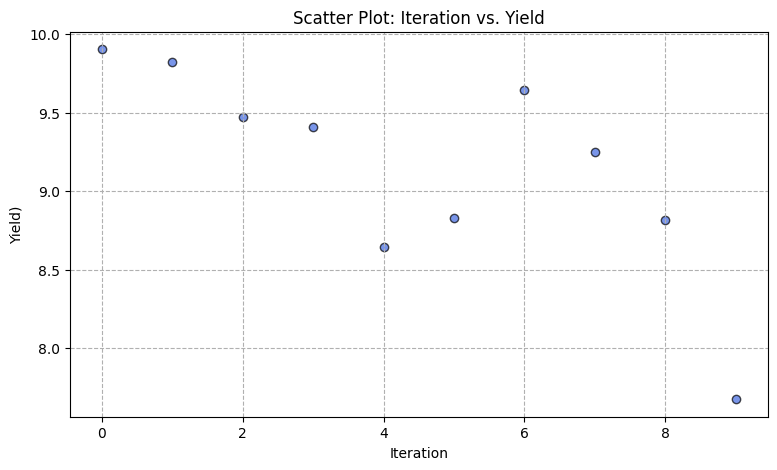

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.scatter(
    list(range(0,10)), y[-10:], color="royalblue", alpha=0.7, edgecolors="k"
)

# 3. Customization
plt.title("Scatter Plot: Iteration vs. Yield")
plt.xlabel("Iteration")
plt.ylabel("Yield)")
plt.grid(True, linestyle="--", alpha=1)

plt.show()